# Lib


In [31]:
import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [32]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load


In [33]:
train_df = pd.read_csv("../data/model/train.csv", parse_dates=["date"])
test_df = pd.read_csv("../data/model/test.csv", parse_dates=["date"])

print(f"train_df: {train_df.shape}")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()}")
print()
print(f"test_df : {test_df.shape}")
print(f"Test : {test_df['date'].min()} -> {test_df['date'].max()}")

train_df: (244770, 25)
Train: 2023-01-01 03:00:00 -> 2025-10-16 23:00:00

test_df : (61200, 25)
Test : 2025-10-17 00:00:00 -> 2026-06-28 23:00:00


In [34]:
ID_COLS = ["location_id", "location_name", "date"]
LABEL_COL = "aqi_category"
LEAKY_COLS = ["us_aqi"]

FEATURE_COLS = [
    c for c in train_df.columns if c not in ID_COLS + [LABEL_COL] + LEAKY_COLS
]

print(f"features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

features: 20
['temperature_2m', 'relative_humidity_2m', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'sunshine_duration', 'boundary_layer_height', 'dew_point_2m', 'hour', 'month', 'day_of_week', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'us_aqi_lag1', 'us_aqi_lag3']


# Func


## utils


In [35]:
def prepare_encoder(
    df: pd.DataFrame,
    feature_cols: list,
    label_col: str,
    label_encoder: LabelEncoder = None,
):
    X = df[feature_cols].copy()

    if label_encoder is None:
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(df[label_col])
    else:
        y = label_encoder.transform(df[label_col])

    return X, y, label_encoder

## train


In [36]:
def train_model(model, X_train: pd.DataFrame, y_train: np.ndarray):
    model.fit(X_train, y_train)
    return model

## eval


In [37]:
def eval_model(
    model,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    label_encoder: LabelEncoder,
    model_name: str = "model",
) -> pd.DataFrame:
    y_pred = model.predict(X_test)

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    return pd.DataFrame([metrics])


def plot_confusion_matrix(
    model,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    label_encoder: LabelEncoder,
    model_name: str = "model",
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="coolwarm",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## predict


In [38]:
def predict_model(
    model,
    df: pd.DataFrame,
    feature_cols: list,
    label_encoder: LabelEncoder,
    column_transformer: ColumnTransformer,
    n_samples: int = 10,
    random_state: int = SEED,
) -> pd.DataFrame:
    n_samples = min(n_samples, len(df))
    sample_df = df.sample(n=n_samples, random_state=random_state).copy()

    X_sample_raw = sample_df[feature_cols]
    X_sample_scaled = column_transformer.transform(X_sample_raw)

    y_pred_encoded = model.predict(X_sample_scaled)
    y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

    sample_df["predicted"] = y_pred_labels

    return sample_df

# Main


## Preprocessing


## Encoder


In [39]:
# Label encoder
X_train, y_train, label_encoder = prepare_encoder(train_df, FEATURE_COLS, LABEL_COL)
X_test, y_test, _ = prepare_encoder(
    test_df, FEATURE_COLS, LABEL_COL, label_encoder=label_encoder
)
print("Classes:", list(enumerate(label_encoder.classes_)))
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Classes: [(0, 'good'), (1, 'moderate'), (2, 'unhealthy'), (3, 'unhealthy for sensitive groups'), (4, 'very unhealthful')]
X_train shape: (244770, 20) | X_test shape: (61200, 20)


## Scaler


In [40]:
# Cols to scale and not scale
NON_SCALE_COLS = [
    "weather_code",
    "month",
    "day_of_week",
    "season",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]
NON_SCALE_COLS = [c for c in NON_SCALE_COLS if c in FEATURE_COLS]
SCALE_COLS = [c for c in FEATURE_COLS if c not in NON_SCALE_COLS]

print(f"Cols to scale: {len(SCALE_COLS)}")
print(SCALE_COLS)

Cols to scale: 13
['temperature_2m', 'relative_humidity_2m', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'sunshine_duration', 'boundary_layer_height', 'dew_point_2m', 'hour', 'us_aqi_lag1', 'us_aqi_lag3']


In [41]:
column_transformer = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), SCALE_COLS),
    ],
    remainder="passthrough",
)

X_train_scaled = column_transformer.fit_transform(X_train)
X_test_scaled = column_transformer.transform(X_test)

final_columns = SCALE_COLS + NON_SCALE_COLS

X_train = pd.DataFrame(
    X_train_scaled, columns=final_columns, index=train_df.index[: len(X_train_scaled)]
)
X_test = pd.DataFrame(
    X_test_scaled, columns=final_columns, index=test_df.index[: len(X_test_scaled)]
)

In [42]:
X_train.head()

,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,sunshine_duration,boundary_layer_height,dew_point_2m,hour,us_aqi_lag1,us_aqi_lag3,weather_code,month,day_of_week,season,is_weekend,hour_sin,hour_cos
0,-0.630471,-0.025310,-0.2524,0.914072,0.666995,-1.383363,0.281932,-0.848236,-0.663377,-0.686607,-1.228221,0.745242,0.772687,3.0,1.0,6.0,1.0,0.0,0.707107,0.707107
1,-1.702297,1.025132,-0.2524,1.019512,0.666995,-1.121497,1.869109,-0.848236,1.754574,-0.752952,-1.228221,0.745242,0.772687,3.0,1.0,6.0,1.0,0.0,0.707107,0.707107
2,-1.867194,-0.724014,-0.2524,0.590948,0.666995,-0.149733,-1.741347,-0.848236,0.872022,-3.318292,-1.228221,2.478440,2.532979,3.0,1.0,6.0,1.0,0.0,0.707107,0.707107
3,-2.032090,-0.571644,-0.2524,-0.476359,0.666995,-0.330207,-1.548849,-0.848236,0.158726,-3.296177,-1.228221,-0.929595,-0.933038,3.0,1.0,6.0,1.0,0.0,0.707107,0.707107
4,-2.246455,0.026958,-0.2524,-1.958981,0.666995,-0.840123,-1.663100,-0.848236,2.008459,-2.721187,-1.228221,0.963786,1.057077,3.0,1.0,6.0,1.0,0.0,0.707107,0.707107


## SMOTE


In [43]:
unique, counts = np.unique(y_train, return_counts=True)
df_before = pd.DataFrame(
    {
        "class": label_encoder.classes_,
        "count": counts,
        "percentage (%)": (counts / len(y_train) * 100).round(2),
    }
)
df_before

,class,count,percentage (%)
0,good,47002,19.20
1,moderate,171038,69.88
2,unhealthy,2753,1.12
3,unhealthy for sensitive groups,23897,9.76
4,very unhealthful,80,0.03


In [44]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [45]:
unique_res, counts_res = np.unique(y_train_res, return_counts=True)
df_after = pd.DataFrame(
    {
        "class": label_encoder.classes_,
        "count": counts_res,
        "percentage (%)": (counts_res / len(y_train_res) * 100).round(1),
    }
)
df_after

,class,count,percentage (%)
0,good,171038,20.0
1,moderate,171038,20.0
2,unhealthy,171038,20.0
3,unhealthy for sensitive groups,171038,20.0
4,very unhealthful,171038,20.0


In [46]:
X_train = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train = y_train_res

## Define model


In [47]:
models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=SEED
    ),
    "SVM": LinearSVC(class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric="mlogloss",
        n_jobs=-1,
    ),
}

## Train


In [48]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name} ...")
    trained_models[name] = train_model(model, X_train, y_train)

Training LogisticRegression ...
Training SVM ...
Training RandomForest ...
Training XGBoost ...


## Eval


In [49]:
eval_results = []

for name, model in trained_models.items():
    result_df = eval_model(model, X_test, y_test, label_encoder, model_name=name)
    eval_results.append(result_df)

comparison_df = pd.concat(eval_results, ignore_index=True)
comparison_df = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)
comparison_df.round(4)

,model_name,accuracy,precision,recall,f1,f1_weighted
0,XGBoost,0.9751,0.9261,0.9403,0.9330,0.9752
1,LogisticRegression,0.9443,0.8499,0.9473,0.8930,0.9460
2,RandomForest,0.9706,0.9115,0.8129,0.8330,0.9705
3,SVM,0.8006,0.6440,0.7981,0.6826,0.8257


In [59]:
for name, model in trained_models.items():
    print(f"{name}:")
    print(
        classification_report(
            y_test,
            model.predict(X_test),
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )
    print("-" * 80)

LogisticRegression:
                                precision    recall  f1-score   support

                          good       0.95      0.97      0.96      7483
                      moderate       0.99      0.94      0.97     42416
                     unhealthy       0.76      0.97      0.85      1550
unhealthy for sensitive groups       0.81      0.93      0.86      9673
              very unhealthful       0.74      0.92      0.82        78

                      accuracy                           0.94     61200
                     macro avg       0.85      0.95      0.89     61200
                  weighted avg       0.95      0.94      0.95     61200

--------------------------------------------------------------------------------
SVM:
                                precision    recall  f1-score   support

                          good       0.92      0.99      0.95      7483
                      moderate       0.96      0.84      0.90     42416
                     unhea

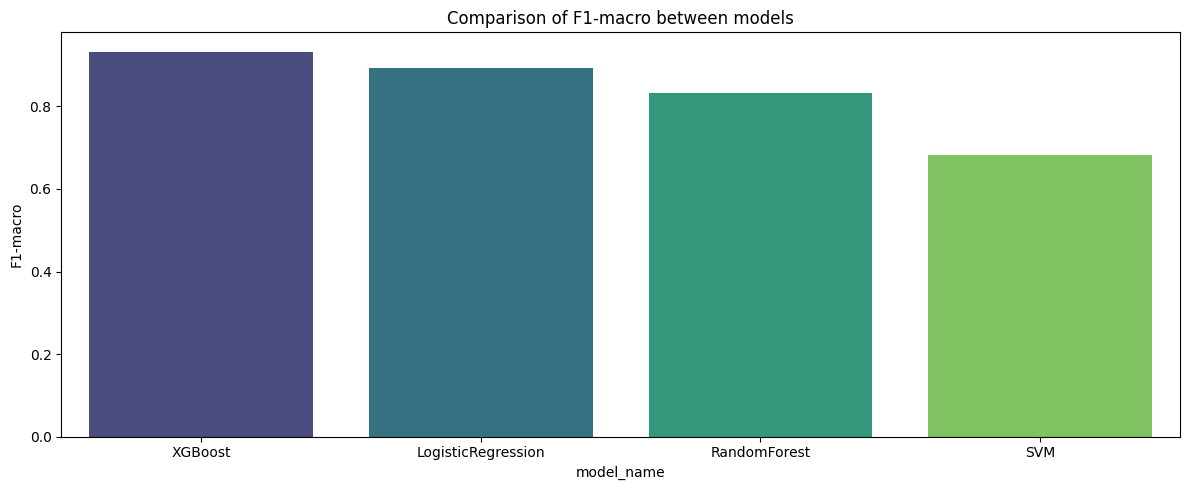

In [51]:
plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_df, x="model_name", y="f1", palette="viridis")
plt.title("Comparison of F1-macro between models")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [52]:
best_model_name = comparison_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model by F1-macro: {best_model_name}")

Best model by F1-macro: XGBoost


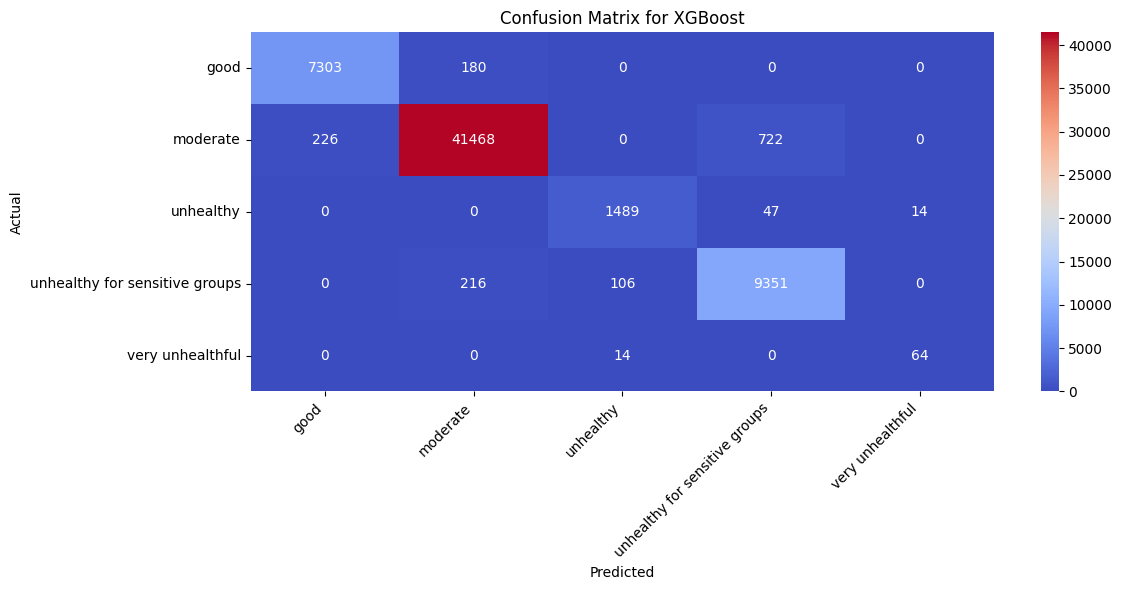

In [53]:
plot_confusion_matrix(
    best_model, X_test, y_test, label_encoder, model_name=best_model_name
)

## Predict


In [54]:
n_samples = 10
sample_result = predict_model(
    model=best_model,
    df=test_df,
    feature_cols=FEATURE_COLS,
    label_encoder=label_encoder,
    column_transformer=column_transformer,
    n_samples=n_samples,
)

sample_result

,location_id,location_name,date,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,...,day_of_week,is_weekend,season,hour_sin,hour_cos,us_aqi_lag1,us_aqi_lag3,us_aqi,aqi_category,predicted
50546,1565022,Thu Dau Mot,2026-05-15 14:00:00,35.40,52.479332,0.0,1003.46606,98.0,10.274200,273.012730,...,4,0,1,-0.500000,-8.660254e-01,95.212776,95.230500,95.195045,moderate,moderate
49529,1566559,Tay Ninh,2026-05-11 08:00:00,29.50,77.728035,0.0,1009.44745,100.0,5.247857,120.963690,...,0,0,1,0.866025,-5.000000e-01,120.864570,123.593750,120.447910,unhealthy for sensitive groups,unhealthy for sensitive groups
41114,9075789,Long Khánh,2026-04-06 07:00:00,24.80,89.472940,0.0,991.88190,10.0,9.703319,139.514070,...,0,0,0,0.965926,-2.588190e-01,58.803190,59.618793,58.076240,moderate,moderate
13667,8594709,Thanh Pho Ba Ria,2025-12-12 22:00:00,24.60,88.647575,0.0,1010.35614,98.0,6.601363,78.996506,...,4,0,0,-0.500000,8.660254e-01,41.280148,42.439700,41.354170,good,good
57780,1582436,Dong Xoai,2026-06-14 18:00:00,25.15,95.333720,1.6,998.99854,67.0,2.052316,74.744830,...,6,1,1,-1.000000,-1.836970e-16,122.406456,93.069710,126.020410,unhealthy for sensitive groups,unhealthy for sensitive groups
17089,1587923,Bien Hoa,2025-12-27 04:00:00,22.95,82.704030,0.0,1008.60180,100.0,7.029225,2.935620,...,5,1,0,0.866025,5.000000e-01,103.562500,109.208320,101.812510,unhealthy for sensitive groups,unhealthy for sensitive groups
15759,1587923,Bien Hoa,2025-12-21 15:00:00,32.50,50.809020,0.0,1006.22516,39.0,4.349896,24.443953,...,6,1,0,-0.707107,-7.071068e-01,101.302080,104.166670,100.145830,unhealthy for sensitive groups,unhealthy for sensitive groups
3715,1565022,Thu Dau Mot,2025-11-01 11:00:00,29.15,80.742615,0.4,1010.82837,89.0,6.489992,303.690100,...,5,1,0,0.258819,-9.659258e-01,78.945040,77.544330,79.521270,moderate,moderate
14499,1583518,Dĩ An,2025-12-16 09:00:00,27.70,67.968216,0.0,1008.08704,90.0,4.553680,18.435053,...,1,0,0,0.707107,-7.071068e-01,87.952110,88.856384,87.553180,moderate,moderate
55459,1583518,Dĩ An,2026-06-05 01:00:00,26.20,95.086120,0.0,1005.57680,98.0,9.511088,209.475800,...,4,0,1,0.258819,9.659258e-01,91.799640,91.622340,91.693260,moderate,moderate


In [55]:
correct = (sample_result["aqi_category"] == sample_result["predicted"]).sum()
print(f"Predictions correct: {correct}/{n_samples}")

Predictions correct: 10/10


# Save model


In [56]:
MODEL_DIR = "../models"

In [ ]:
joblib.dump(best_model, os.path.join(MODEL_DIR, f"{best_model_name}_best_model.joblib"))
joblib.dump(label_encoder, os.path.join(MODEL_DIR, "label_encoder.joblib"))
joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, "feature_cols.joblib"))
joblib.dump(column_transformer, os.path.join(MODEL_DIR, "column_transformer.joblib"))

print(
    f"Best model saved to {os.path.join(MODEL_DIR, f'{best_model_name}_best_model.joblib')}"
)

Best model saved to ../models\XGBoost_best_model.joblib
